In [1]:
# Environment and Import
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys 
import os 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"..")))
from src.yieldcurve import YieldCurve
from src.derivatives import EuropeanCall, EuropeanPut
print(sys.version)

3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [2]:
# cosntruct yieldcure
maturities = [0.5, 1.0, 2.0, 3.0]
zero_rates = [0.03, 0.032, 0.035, 0.038]

yc = YieldCurve(maturities, zero_rates)


<function matplotlib.pyplot.show(close=None, block=None)>

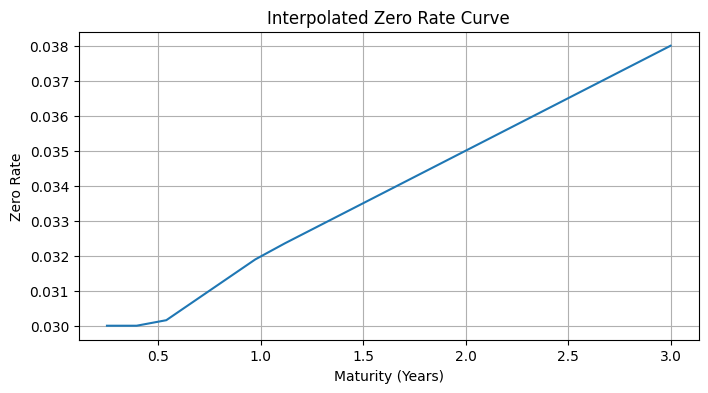

In [3]:
# yieldcurve sanity check
test_maturities = np.linspace(0.25, 3.0, 20)
rates = [yc.get_zero_rate(T) for T in test_maturities]
dfs = [yc.get_discount_factor(T) for T in test_maturities]

plt.figure(figsize=(8,4))
plt.plot(test_maturities, rates)
plt.title("Interpolated Zero Rate Curve")
plt.xlabel("Maturity (Years)")
plt.ylabel("Zero Rate")
plt.grid(True)
plt.show

In [4]:
# create derivatives
S0 = 100
K = 100
T = 1.0
sigma = 0.2

call = EuropeanCall(
    S0 = S0,
    K = K,
    T = T,
    sigma = sigma,
    yield_curve = yc
)

put = EuropeanPut(
    S0 = S0,
    K = K,
    T = T,
    sigma = sigma,
    yield_curve = yc
)

In [5]:
call_price = float(round(call.price(), 4))
put_price = float(round(put.price(), 4))

print(f"The call price is: {call_price}")
print(f"The put price is: {put_price}")


The call price is: 9.5146
The put price is: 6.3653


In [ ]:
other sense checks: vol, strike, underlying, maturity

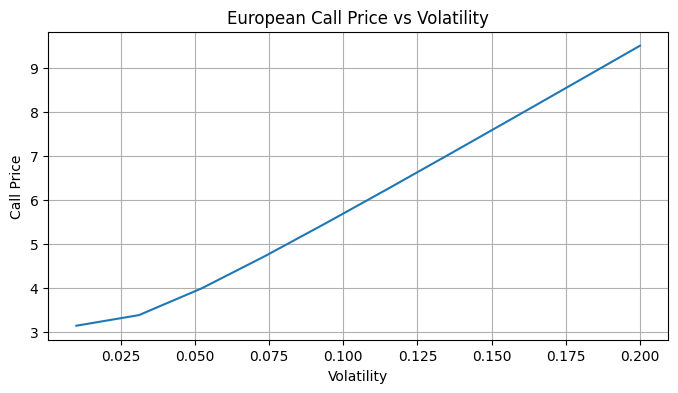

In [9]:
# test vol
vols = np.linspace(0.01, 0.2, 10)
call_prices = []

for v in vols:
    tmp_call = EuropeanCall(S0, K, T, v, yc)
    call_prices.append(tmp_call.price())

plt.figure(figsize=(8,4))
plt.plot(vols, call_prices)
plt.title("European Call Price vs Volatility")
plt.xlabel("Volatility")
plt.ylabel("Call Price")
plt.grid(True)
plt.show()